# Full-zeroed vs compact GEMM on Llama activations

This notebook isolates the numerical difference between activation pruning and structural pruning. It loads Llama, captures realistic inputs to `o_proj` at several attention layers, creates compact copies of those projections, and compares mathematically equivalent GEMMs in BF16, FP16, and FP32.

The full model is retained in `model`; structurally pruned `o_proj` blocks are retained in `compact_o_layers`. A second complete 8B model is intentionally not loaded.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from dotenv import load_dotenv
from transformers import AutoModelForCausalLM, AutoTokenizer

PROJECT_ROOT = Path("/glazkov-dev/LoRa-Transfer-Pruning")
load_dotenv("/glazkov-dev/.env")
sns.set_theme(style="whitegrid")

In [2]:
MODEL = "meta-llama/Llama-3.1-8B-Instruct"
DEVICE = "cuda:0"
MODEL_DTYPE = torch.bfloat16

# Several depths without retaining activations for all 32 layers.
LAYER_INDICES = [0, 7, 15, 23, 31]
NUM_BATCHES = 16
BATCH_SIZE = 1
CONTEXT_LENGTH = 256
ACTIVATIONS_PER_BATCH = 16
EVAL_CHUNK_SIZE = 1

# Local coordinates inside every attention head. RoPE partners are added below.
LOCAL_PRUNED_INDICES = [2, 6, 10, 14, 15, 23, 31, 75]
DTYPES = [torch.bfloat16, torch.float16, torch.float32]
SEED = 42
torch.manual_seed(SEED)

## Load the model and evaluation text

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    dtype=MODEL_DTYPE,
    device_map=DEVICE,
).eval()

config = model.config
print("model dtype:", next(model.parameters()).dtype)
print("layers:", config.num_hidden_layers)
print("heads/head_dim:", config.num_attention_heads, config.head_dim)

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

model dtype: torch.bfloat16
layers: 32
heads/head_dim: 32 128


In [4]:
validation = load_dataset( 
    "Salesforce/wikitext",
    "wikitext-2-raw-v1",
    split="validation",
)
#text not for training, but for eval only!
text = "\n\n".join(row for row in validation["text"] if row.strip()) 
tokens = tokenizer(text, add_special_tokens=False, return_tensors="pt").input_ids[0]
required = NUM_BATCHES * BATCH_SIZE * CONTEXT_LENGTH
if tokens.numel() < required:
    raise RuntimeError(f"Need {required} tokens, found {tokens.numel()}")
evaluation_blocks = tokens[:required].reshape(NUM_BATCHES, BATCH_SIZE, CONTEXT_LENGTH)
evaluation_blocks.shape

Token indices sequence length is longer than the specified maximum sequence length for this model (252725 > 131072). Running this sequence through the model will result in indexing errors


torch.Size([16, 1, 256])

## Define structural pruning coordinates and compact `o_proj` blocks

For each selected local head coordinate, its RoPE half-pair is included. The resulting coordinates are repeated over all attention heads. The full block computes with zeros at these input coordinates; the compact block physically removes the same input columns.

In [5]:
def close_rope_pairs(indices, head_dim):
    half = head_dim // 2
    closed = set(int(i) for i in indices)
    for idx in list(closed):
        closed.add(idx + half if idx < half else idx - half)
    return torch.tensor(sorted(closed), dtype=torch.long)


local_pruned = close_rope_pairs(LOCAL_PRUNED_INDICES, config.head_dim)
pruned_indices = torch.cat([
    local_pruned + head * config.head_dim
    for head in range(config.num_attention_heads)
]).sort().values
keep_mask = torch.ones(config.num_attention_heads * config.head_dim, dtype=torch.bool)
keep_mask[pruned_indices] = False
keep_indices = keep_mask.nonzero(as_tuple=False).flatten()

print("local pruned:", local_pruned.tolist())
print("full/compact K:", keep_mask.numel(), keep_indices.numel())
print("removed:", pruned_indices.numel())

local pruned: [2, 6, 10, 11, 14, 15, 23, 31, 66, 70, 74, 75, 78, 79, 87, 95]
full/compact K: 4096 3584
removed: 512


In [6]:
full_o_layers = {
    layer_idx: model.model.layers[layer_idx].self_attn.o_proj
    for layer_idx in LAYER_INDICES
}
compact_o_layers = nn.ModuleDict()
for layer_idx, full_layer in full_o_layers.items():
    compact = nn.Linear(
        keep_indices.numel(),
        full_layer.out_features,
        bias=full_layer.bias is not None,
        dtype=full_layer.weight.dtype,
        device="cpu",
    )
    compact.weight.data.copy_(full_layer.weight.detach().cpu().index_select(1, keep_indices))
    if full_layer.bias is not None:
        compact.bias.data.copy_(full_layer.bias.detach().cpu())
    compact.requires_grad_(False)
    compact_o_layers[str(layer_idx)] = compact

print("full block:   ", full_o_layers[LAYER_INDICES[0]])
print("compact block:", compact_o_layers[str(LAYER_INDICES[0])])

full block:    Linear(in_features=4096, out_features=4096, bias=False)
compact block: Linear(in_features=3584, out_features=4096, bias=False)


## Capture realistic inputs to `o_proj`

Only a fixed number of token activations per batch and layer is copied to CPU. This provides many realistic samples without retaining complete hidden states for every layer.

In [7]:
captured_inputs = {layer_idx: [] for layer_idx in LAYER_INDICES}
handles = []

def make_capture_hook(layer_idx):
    def hook(module, args):
        activation = args[0].detach().reshape(-1, args[0].shape[-1])
        count = min(ACTIVATIONS_PER_BATCH, activation.shape[0])
        positions = torch.linspace(
            0, activation.shape[0] - 1, count, device=activation.device
        ).round().long()
        captured_inputs[layer_idx].append(
            activation.index_select(0, positions).cpu().clone()
        )
    return hook

for layer_idx, layer in full_o_layers.items():
    handles.append(layer.register_forward_pre_hook(make_capture_hook(layer_idx)))

try:
    with torch.inference_mode():
        for batch in evaluation_blocks:
            model(input_ids=batch.to(DEVICE), use_cache=False)
finally:
    for handle in handles:
        handle.remove()

captured_inputs = {
    layer_idx: torch.cat(parts, dim=0)
    for layer_idx, parts in captured_inputs.items()
}
{layer_idx: tuple(value.shape) for layer_idx, value in captured_inputs.items()}

{0: (256, 4096),
 7: (256, 4096),
 15: (256, 4096),
 23: (256, 4096),
 31: (256, 4096)}

## Compare GEMMs

Two full representations are tested: zeros at the original internal coordinates, and the same compact data followed by trailing zeros. Metrics are calculated independently for every captured activation vector. FP32 uses `highest` matmul precision to avoid TF32.

In [8]:
def per_sample_metrics(reference, candidate):
    delta = candidate.float() - reference.float()
    abs_delta = delta.abs()
    denominator = reference.float().norm(dim=-1).clamp_min(1e-12)
    return {
        "max": abs_delta.amax(dim=-1),
        "mean": abs_delta.mean(dim=-1),
        "rmse": delta.square().mean(dim=-1).sqrt(),
        "rel_l2": delta.norm(dim=-1) / denominator,
        "different": (candidate != reference).sum(dim=-1),
    }


def append_rows(rows, metrics, dtype, layer_idx, scenario, sample_offset):
    cpu_metrics = {name: value.cpu() for name, value in metrics.items()}
    for local_idx in range(len(cpu_metrics["max"])):
        rows.append({
            "dtype": str(dtype).removeprefix("torch."),
            "layer": layer_idx,
            "scenario": scenario,
            "sample": sample_offset + local_idx,
            **{name: value[local_idx].item() for name, value in cpu_metrics.items()},
        })

In [9]:
full_o_layers

{0: Linear(in_features=4096, out_features=4096, bias=False),
 7: Linear(in_features=4096, out_features=4096, bias=False),
 15: Linear(in_features=4096, out_features=4096, bias=False),
 23: Linear(in_features=4096, out_features=4096, bias=False),
 31: Linear(in_features=4096, out_features=4096, bias=False)}

In [10]:
# full_layer = full_o_layers[0]
# full_weight = full_layer.weight.detach().to(device=device, dtype=dtype)
# full_weight.abs().mean()

In [11]:
# full_weight.std() = 0.0083

In [ ]:
INCREASE_WEIGHTS_AMPLITUDE = True

rows = []
device = torch.device(DEVICE)
keep_device = keep_indices.to(device)
pruned_device = pruned_indices.to(device)
full_k = keep_mask.numel()
gap_size = pruned_indices.numel()
old_precision = torch.get_float32_matmul_precision()
torch.set_float32_matmul_precision("highest")

try:
    with torch.inference_mode():
        for dtype in DTYPES:
            for layer_idx in LAYER_INDICES:
                full_layer = full_o_layers[layer_idx]
                full_weight = full_layer.weight.detach().to(device=device, dtype=dtype)
                
                weight_scale = 1
                compact_weight = compact_o_layers[str(layer_idx)].weight.to(device=device, dtype=dtype)
                
                if (INCREASE_WEIGHTS_AMPLITUDE):
                    weight_scale = (1 / full_weight.std())
                    full_weight = full_weight * weight_scale
                    compact_weight = compact_weight * weight_scale
                
                
                bias = None if full_layer.bias is None else full_layer.bias.detach().to(device=device, dtype=dtype)

                for start in range(0, len(captured_inputs[layer_idx]), EVAL_CHUNK_SIZE):
                    activation = captured_inputs[layer_idx][start:start + EVAL_CHUNK_SIZE].to(
                        device=device, dtype=dtype
                    )
                    compact_activation = activation.index_select(-1, keep_device).contiguous()
                    internal_activation = activation.clone()
                    internal_activation.index_fill_(-1, pruned_device, 0)
                    trailing_activation = F.pad(compact_activation, (0, gap_size)).contiguous()
                    trailing_weight = F.pad(compact_weight, (0, gap_size)).contiguous()

                    compact_output = F.linear(compact_activation, compact_weight, bias)
                    internal_output = F.linear(internal_activation, full_weight, bias)
                    trailing_output = F.linear(trailing_activation, trailing_weight, bias)

                    append_rows(rows, per_sample_metrics(compact_output, internal_output), dtype, layer_idx, "internal zeros", start)
                    append_rows(rows, per_sample_metrics(compact_output, trailing_output), dtype, layer_idx, "trailing zeros", start)
finally:
    torch.set_float32_matmul_precision(old_precision)

results = pd.DataFrame(rows)
results.head()

,dtype,layer,scenario,sample,max,mean,rmse,rel_l2,different
0,bfloat16,0,internal zeros,0,16.115234,0.626989,0.905956,118.607773,4096
1,bfloat16,0,trailing zeros,0,0.000000,0.000000,0.000000,0.000000,0
2,bfloat16,0,internal zeros,1,24.791016,0.444290,0.984895,118.506714,4096
3,bfloat16,0,trailing zeros,1,0.000000,0.000000,0.000000,0.000000,0
4,bfloat16,0,internal zeros,2,30.244141,0.689262,1.338210,118.498634,4096


## Aggregate results

`max` is aggregated with maximum over all activation vectors. `mean`, `RMSE`, and relative L2 are averaged over activation vectors, as requested.

In [13]:
summary = (
    results.groupby(["dtype", "scenario"], as_index=False)
    .agg(
        samples=("sample", "size"),
        max_error=("max", "max"),
        average_mean_error=("mean", "mean"),
        average_rmse=("rmse", "mean"),
        average_rel_l2=("rel_l2", "mean"),
        max_rel_l2=("rel_l2", "max"),
        average_different=("different", "mean"),
    )
)
summary

,dtype,scenario,samples,max_error,average_mean_error,average_rmse,average_rel_l2,max_rel_l2,average_different
0,bfloat16,internal zeros,1280,642.812500,3.349894,4.984635,92.400661,118.696548,4096.0
1,bfloat16,trailing zeros,1280,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,float16,internal zeros,1280,645.796875,3.350204,4.986403,92.386119,118.953461,4096.0
3,float16,trailing zeros,1280,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
4,float32,internal zeros,1280,645.365051,3.349744,4.985612,92.385956,118.930466,4096.0
5,float32,trailing zeros,1280,0.000000,0.000000,0.000000,0.000000,0.000000,0.0


In [14]:
layer_summary = (
    results.groupby(["dtype", "scenario", "layer"], as_index=False)
    .agg(
        max_error=("max", "max"),
        average_mean_error=("mean", "mean"),
        average_rmse=("rmse", "mean"),
        average_rel_l2=("rel_l2", "mean"),
    )
)
layer_summary

,dtype,scenario,layer,max_error,average_mean_error,average_rmse,average_rel_l2
0,bfloat16,internal zeros,0,58.011719,0.507491,1.116084,118.510053
1,bfloat16,internal zeros,7,145.531250,2.398525,3.105552,99.000218
2,bfloat16,internal zeros,15,135.484375,2.817611,3.601997,89.503172
3,bfloat16,internal zeros,23,80.054688,2.082392,2.664220,84.988879
4,bfloat16,internal zeros,31,642.812500,8.943449,14.435324,70.000984
5,bfloat16,trailing zeros,0,0.000000,0.000000,0.000000,0.000000
6,bfloat16,trailing zeros,7,0.000000,0.000000,0.000000,0.000000
7,bfloat16,trailing zeros,15,0.000000,0.000000,0.000000,0.000000
8,bfloat16,trailing zeros,23,0.000000,0.000000,0.000000,0.000000
9,bfloat16,trailing zeros,31,0.000000,0.000000,0.000000,0.000000


## Error distributions

In [15]:
def get_suptitle_from_scenario(scenario):
    return scenario + ". removed " + str(len(pruned_indices)) + " of " + str(keep_mask.__len__()) + " of o_proj in for " + MODEL + " ; \n Activations multiplied to .std()=1.0!"

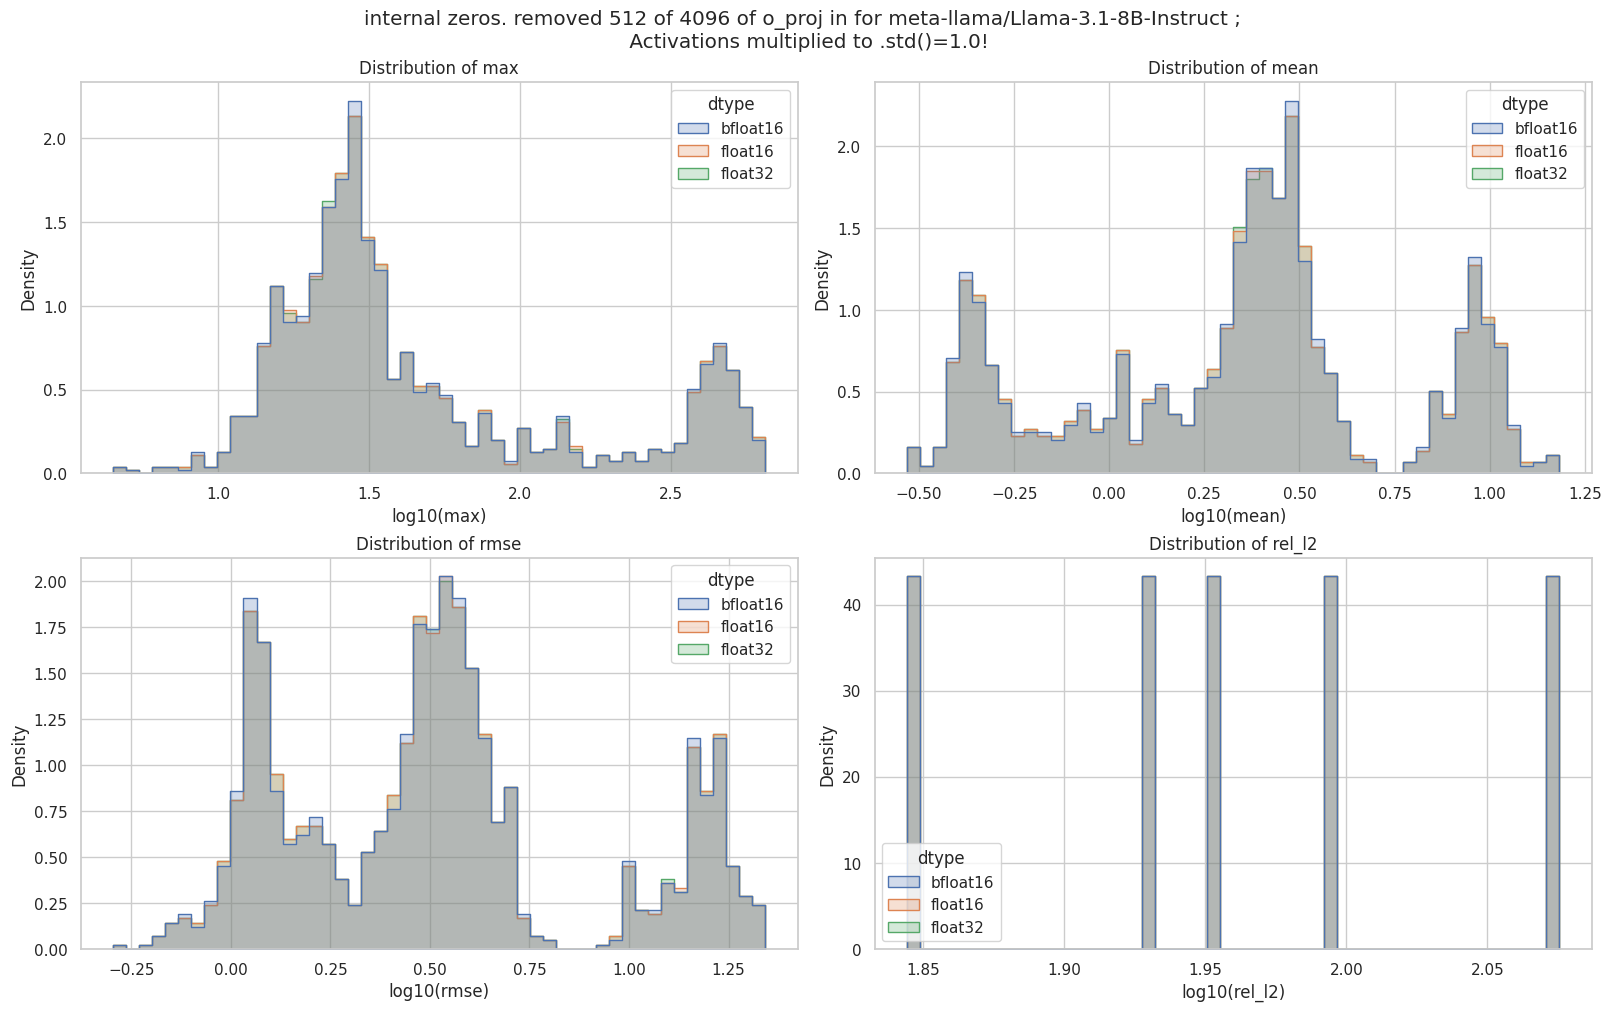

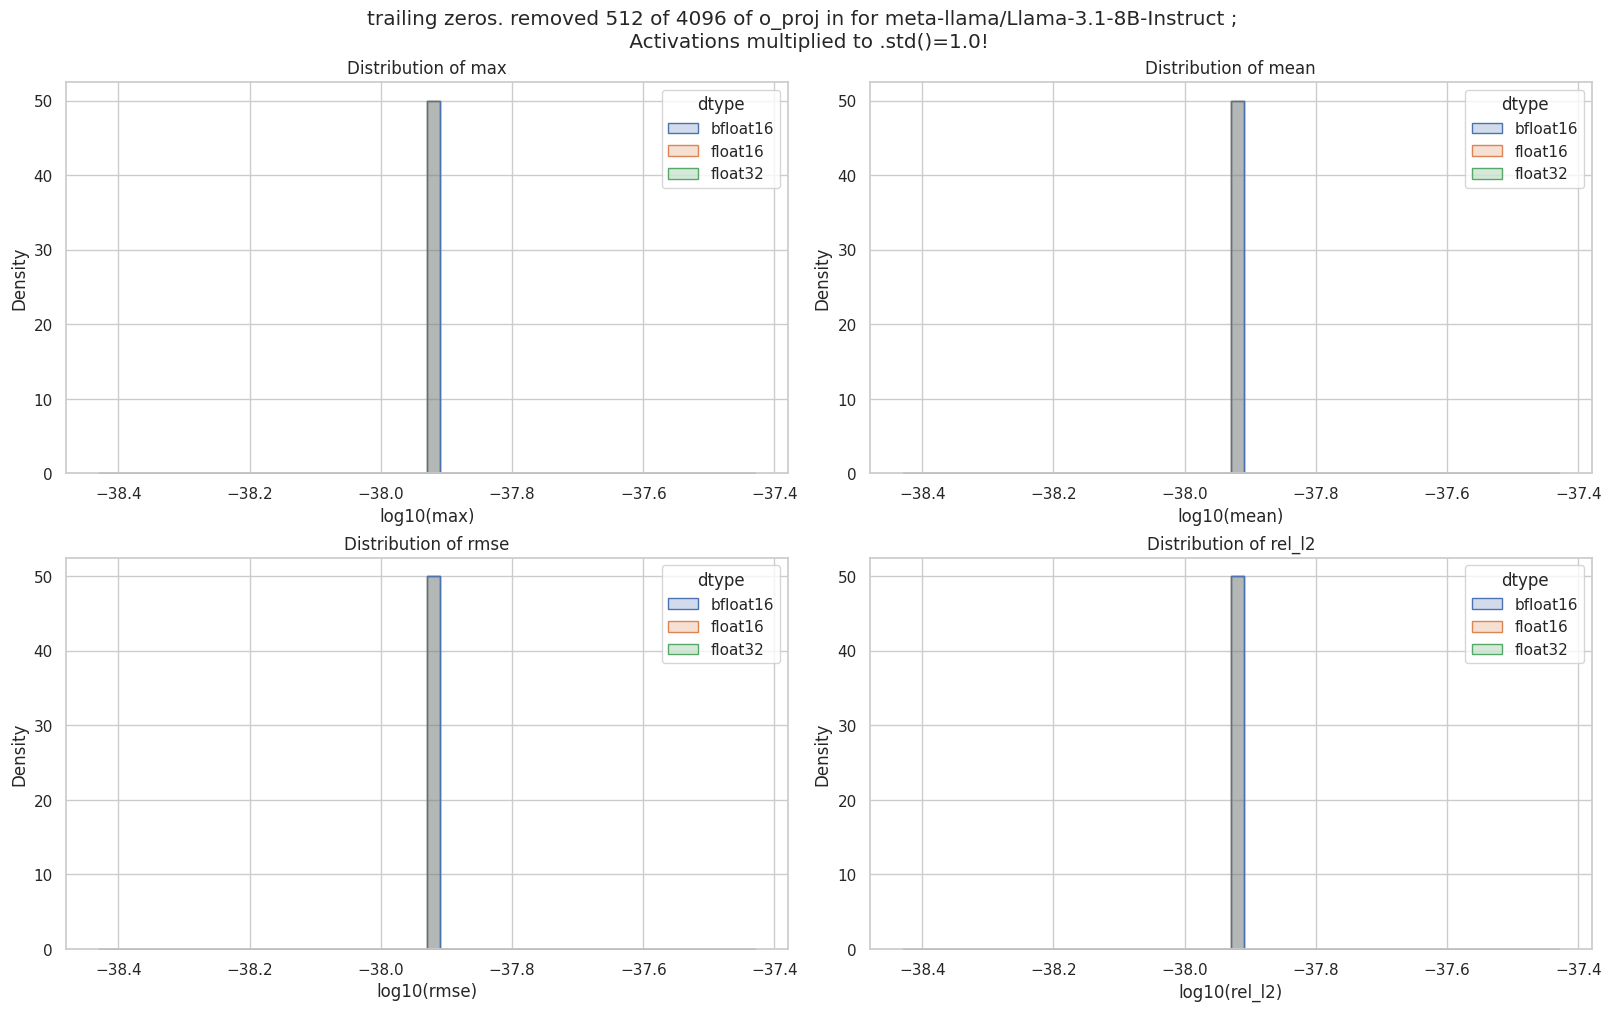

In [16]:
metrics = ["max", "mean", "rmse", "rel_l2"]
eps = np.finfo(np.float32).tiny
plot_results = results.copy()
for metric in metrics:
    plot_results[f"log10_{metric}"] = np.log10(plot_results[metric].clip(lower=eps))

for scenario in plot_results["scenario"].unique():
    scenario_results = plot_results[plot_results["scenario"] == scenario]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    fig.suptitle(get_suptitle_from_scenario(scenario))
    for ax, metric in zip(axes.flat, metrics):
        sns.histplot(
            data=scenario_results,
            x=f"log10_{metric}",
            hue="dtype",
            element="step",
            stat="density",
            common_norm=False,
            bins=50,
            ax=ax,
        )
        ax.set_title(f"Distribution of {metric}")
        ax.set_xlabel(f"log10({metric})")
    plt.show()

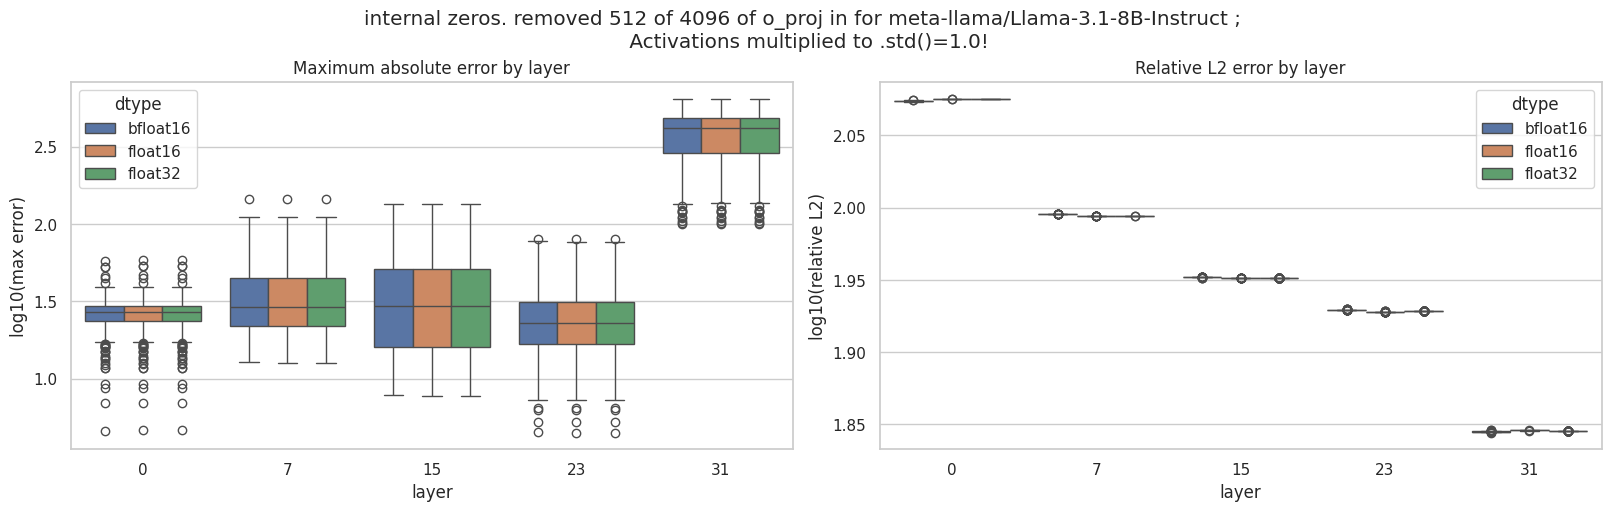

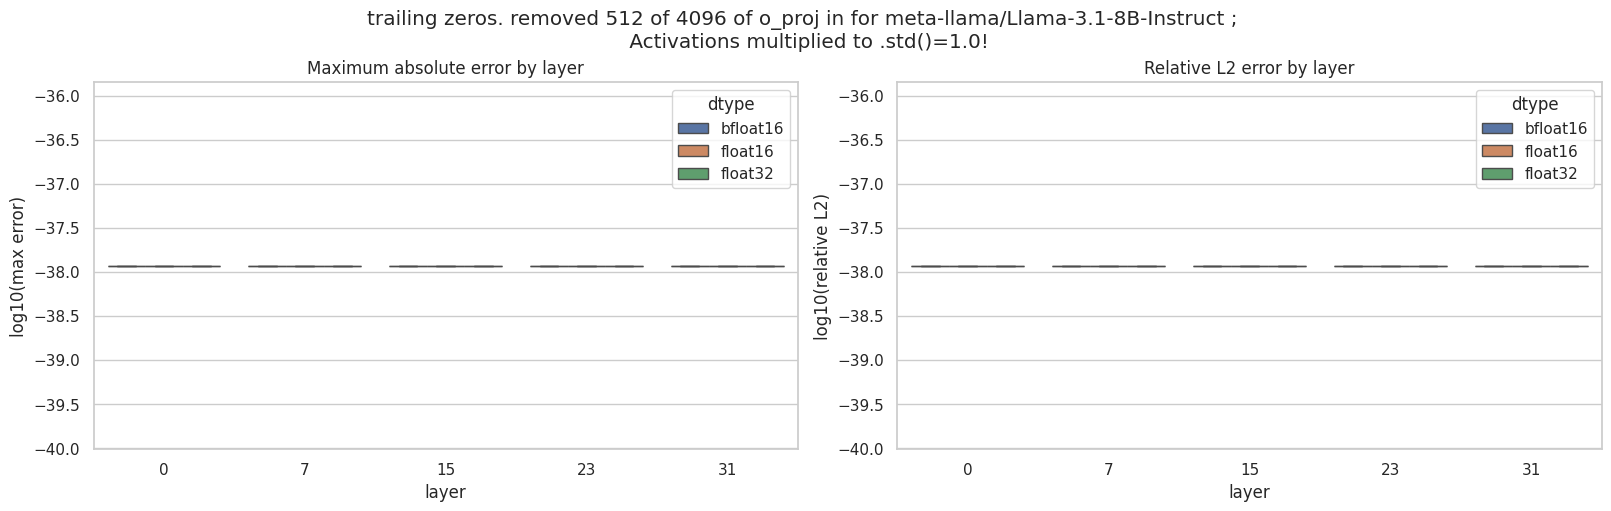

In [17]:
for scenario in plot_results["scenario"].unique():
    scenario_results = plot_results[plot_results["scenario"] == scenario]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    fig.suptitle(get_suptitle_from_scenario(scenario))
    sns.boxplot(data=scenario_results, x="layer", y="log10_max", hue="dtype", ax=axes[0])
    axes[0].set_title("Maximum absolute error by layer")
    axes[0].set_ylabel("log10(max error)")
    sns.boxplot(data=scenario_results, x="layer", y="log10_rel_l2", hue="dtype", ax=axes[1])
    axes[1].set_title("Relative L2 error by layer")
    axes[1].set_ylabel("log10(relative L2)")
    plt.show()

## Optional export

In [18]:
OUTPUT_CSV = PROJECT_ROOT / "experiments/compare_tp_and_our/full_vs_compact_on_llama_results.csv"
# results.to_csv(OUTPUT_CSV, index=False)
print(OUTPUT_CSV)

/glazkov-dev/LoRa-Transfer-Pruning/experiments/compare_tp_and_our/full_vs_compact_on_llama_results.csv
